## Imports and Setup

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import (
    # Models
    RewardModelEnsemble,
    NeuralGreedy, NeuralUCB, NeuralThompson,
    # Policies
    LinUCBPolicy, GreedyPolicy, EpsilonGreedyPolicy, BoltzmannPolicy,
    # Evaluation
    OfflinePolicyEvaluator, actions_to_probs, softmax_probs,
    counterfactual_policy_value,
    # Pipeline
    FeaturePipeline,
    # Data
    TREATMENTS, N_TREATMENTS, IDX_TO_TREATMENT,
    # Utils
    seed_everything, setup_plotting, timer, save_results,
    TREATMENT_COLORS, ensure_dirs,
)
from src.utils import plot_ope_comparison

seed_everything(42)
setup_plotting()
ensure_dirs()
print("Setup complete")

2026-04-16 04:02:04.120 | INFO     | src.utils:seed_everything:436 - Seeds set to 42


Setup complete


## Load Data and Prepare

In [2]:

df = pd.read_csv("../data/bandit_dataset.csv")

# Unscaled for XGBoost/VW
pipe_u = FeaturePipeline(scale=False, add_interactions=True)
X_train_u, X_test_u, meta_u = pipe_u.fit_transform_split(df, test_size=0.2, seed=42)

# Scaled for neural
pipe_s = FeaturePipeline(scale=True, add_interactions=True)
X_train_s, X_test_s, meta_s = pipe_s.fit_transform_split(df, test_size=0.2, seed=42)

feature_names = meta_u['feature_names']
input_dim = X_train_s.shape[1]

print(f"Test set: {X_test_u.shape[0]} samples")
print(f"Counterfactuals available: {meta_u.get('cf_test') is not None}")
print(f"Optimal actions available: {meta_u.get('opt_test') is not None}")

2026-04-16 04:02:04.284 | INFO     | src.feature_engineering:fit:158 - FeaturePipeline fitted: 25 features, scale=False
2026-04-16 04:02:04.307 | INFO     | src.feature_engineering:fit_transform_split:247 - Split: train=16000, test=4000, features=25
2026-04-16 04:02:04.342 | INFO     | src.feature_engineering:fit:158 - FeaturePipeline fitted: 25 features, scale=True
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
2026-04-16 04:02:04.366 | INFO     | src.feature_engineering:fit_transform_split:247 - Split: train=16000, test=4000, features=25


Test set: 4000 samples
Counterfactuals available: True
Optimal actions available: True


##  Re-train All Models (or Load Saved)

In [3]:

# ── XGBoost Ensemble ──
print("Training XGBoost ensemble...")
xgb_model = RewardModelEnsemble()
xgb_model.fit(X_train_u, meta_u['a_train'], meta_u['y_train'], feature_names=feature_names)

# ── NeuralGreedy ──
print("Training NeuralGreedy...")
ng_model = NeuralGreedy(input_dim=input_dim, hidden_dims=[128, 64], device="cpu")
ng_model.train(X_train_s, meta_s['a_train'], meta_s['y_train'], epochs=60, verbose=False)

# ── NeuralUCB ──
print("Training NeuralUCB...")
nucb_model = NeuralUCB(input_dim=input_dim, hidden_dims=[128, 64], alpha=1.0, device="cpu")
nucb_model.train(X_train_s, meta_s['a_train'], meta_s['y_train'], epochs=60, verbose=False)
for i in range(min(5000, len(X_train_s))):
    nucb_model.update_covariance(X_train_s[i], int(meta_s['a_train'][i]))

# ── NeuralThompson ──
print("Training NeuralThompson...")
nts_model = NeuralThompson(input_dim=input_dim, hidden_dims=[128, 64], noise_variance=0.25, device="cpu")
nts_model.train(X_train_s, meta_s['a_train'], meta_s['y_train'], epochs=60, verbose=False)
nts_model.initialize_posterior(X_train_s, meta_s['a_train'].astype(int), meta_s['y_train'].astype(float))  # G-1: bootstrap posterior

print("All models trained")


Training XGBoost ensemble...


2026-04-16 04:02:05.478 | INFO     | src.reward_model:fit:105 -   Metformin    n_train= 5259  mean_reward=0.992
2026-04-16 04:02:06.365 | INFO     | src.reward_model:fit:105 -   GLP-1        n_train= 3250  mean_reward=0.981
2026-04-16 04:02:07.206 | INFO     | src.reward_model:fit:105 -   SGLT-2       n_train= 2879  mean_reward=1.123
2026-04-16 04:02:08.106 | INFO     | src.reward_model:fit:105 -   DPP-4        n_train= 1754  mean_reward=0.939
2026-04-16 04:02:09.012 | INFO     | src.reward_model:fit:105 -   Insulin      n_train= 2858  mean_reward=0.721
2026-04-16 04:02:09.013 | INFO     | src.reward_model:fit:112 - RewardModelEnsemble fitted: 5 models


Training NeuralGreedy...


2026-04-16 04:02:10.547 | INFO     | src.neural_bandit:__init__:158 - NeuralGreedy initialized: input=25, hidden=[128, 64], device=cpu
2026-04-16 04:02:35.390 | INFO     | src.neural_bandit:train:291 - Training complete: best_val_loss=0.0341, epochs_run=60
2026-04-16 04:02:35.394 | INFO     | src.neural_bandit:__init__:158 - NeuralUCB initialized: input=25, hidden=[128, 64], device=cpu


Training NeuralUCB...


2026-04-16 04:02:59.177 | INFO     | src.neural_bandit:train:291 - Training complete: best_val_loss=0.0335, epochs_run=60
2026-04-16 04:03:00.668 | INFO     | src.neural_bandit:__init__:158 - NeuralThompson initialized: input=25, hidden=[128, 64], device=cpu


Training NeuralThompson...


2026-04-16 04:03:27.716 | INFO     | src.neural_bandit:train:291 - Training complete: best_val_loss=0.0346, epochs_run=60
2026-04-16 04:03:28.613 | INFO     | src.neural_bandit:initialize_posterior:922 - Posterior bootstrapped from 16000 rows (G-1 fix).


All models trained


## Generate Policy Action Probabilities for Each Model

In [4]:
# Each policy needs (n_test, K) probability matrix

# 1. XGBoost Greedy — deterministic
xgb_actions = xgb_model.predict_best_action(X_test_u)
xgb_probs = actions_to_probs(xgb_actions)

# 2. XGBoost Softmax — soft probabilities
xgb_pred_rewards = xgb_model.predict_all(X_test_u)
xgb_soft_probs = softmax_probs(xgb_pred_rewards, temperature=0.5)

# 4. NeuralGreedy — deterministic
ng_actions = ng_model.select_actions(X_test_s)
ng_probs = actions_to_probs(ng_actions)

# 5. NeuralUCB — deterministic (greedy on UCB scores)
nucb_actions = nucb_model.select_actions(X_test_s)
nucb_probs = actions_to_probs(nucb_actions)

# 6. NeuralThompson — sample-based (run multiple times for soft probs)
n_test = len(X_test_s)
nts_prob_accum = np.zeros((n_test, N_TREATMENTS))
n_samples = 50
for _ in range(n_samples):
    for i in range(n_test):
        a, _ = nts_model.select_action(X_test_s[i])
        nts_prob_accum[i, a] += 1
nts_probs = nts_prob_accum / n_samples

# 7. Logging policy (baseline)
logging_probs = actions_to_probs(meta_u['a_test'])

# 8. Random policy
random_probs = np.ones((n_test, N_TREATMENTS)) / N_TREATMENTS

policies = {
    "Random": random_probs,
    "Logging": logging_probs,
    "XGB_Greedy": xgb_probs,
    "XGB_Softmax": xgb_soft_probs,
    "NeuralGreedy": ng_probs,
    "NeuralUCB": nucb_probs,
    "NeuralThompson": nts_probs,
}

print(f"Generated action probabilities for {len(policies)} policies")
for name, probs in policies.items():
    print(f"  {name:<20} shape={probs.shape}  avg_entropy={-(probs * np.log(probs + 1e-10)).sum(1).mean():.3f}")


Generated action probabilities for 7 policies
  Random               shape=(4000, 5)  avg_entropy=1.609
  Logging              shape=(4000, 5)  avg_entropy=-0.000
  XGB_Greedy           shape=(4000, 5)  avg_entropy=-0.000
  XGB_Softmax          shape=(4000, 5)  avg_entropy=1.041
  NeuralGreedy         shape=(4000, 5)  avg_entropy=-0.000
  NeuralUCB            shape=(4000, 5)  avg_entropy=-0.000
  NeuralThompson       shape=(4000, 5)  avg_entropy=0.133


## Initialize Offline Policy Evaluator

In [5]:

# XGBoost predictions serve as the reward model for DM and DR
reward_predictions = xgb_model.predict_all(X_test_u)

evaluator = OfflinePolicyEvaluator(
    X=X_test_u,
    actions=meta_u['a_test'],
    rewards=meta_u['y_test'],
    pscores=meta_u['p_test'],
    counterfactuals=meta_u['cf_test'],
    reward_predictions=reward_predictions,
)

print("OfflinePolicyEvaluator initialized")
print(f"  Estimators: IPS, SNIPS, DM, DR + Counterfactual ground truth")

2026-04-16 04:36:12.033 | INFO     | src.evaluation:__init__:301 - OfflinePolicyEvaluator: n=4000, counterfactuals=yes, reward_model=yes


OfflinePolicyEvaluator initialized
  Estimators: IPS, SNIPS, DM, DR + Counterfactual ground truth


## Evaluate All Policies — Full OPE

In [6]:
all_results = {}
for name, probs in policies.items():
    print(f"\nEvaluating: {name}")
    all_results[name] = evaluator.evaluate_policy(probs, policy_name=name)

print("\nAll policies evaluated")


Evaluating: Random


2026-04-16 04:36:12.138 | INFO     | src.evaluation:evaluate_policy:350 - Evaluated 'Random': 5 estimators
2026-04-16 04:36:12.153 | INFO     | src.evaluation:evaluate_policy:350 - Evaluated 'Logging': 5 estimators



Evaluating: Logging

Evaluating: XGB_Greedy


2026-04-16 04:36:12.168 | INFO     | src.evaluation:evaluate_policy:350 - Evaluated 'XGB_Greedy': 5 estimators
2026-04-16 04:36:12.185 | INFO     | src.evaluation:evaluate_policy:350 - Evaluated 'XGB_Softmax': 5 estimators
2026-04-16 04:36:12.200 | INFO     | src.evaluation:evaluate_policy:350 - Evaluated 'NeuralGreedy': 5 estimators
2026-04-16 04:36:12.217 | INFO     | src.evaluation:evaluate_policy:350 - Evaluated 'NeuralUCB': 5 estimators



Evaluating: XGB_Softmax

Evaluating: NeuralGreedy

Evaluating: NeuralUCB


2026-04-16 04:36:12.235 | INFO     | src.evaluation:evaluate_policy:350 - Evaluated 'NeuralThompson': 5 estimators



Evaluating: NeuralThompson

All policies evaluated


## IPS Estimates Comparison

INVERSE PROPENSITY SCORING (IPS) ESTIMATES
        policy  value  std_error  ci_lower  ci_upper
       Logging 3.0580     0.0514    2.9573    3.1587
     NeuralUCB 1.5108     0.0415    1.4294    1.5922
    XGB_Greedy 1.5051     0.0392    1.4283    1.5818
  NeuralGreedy 1.4910     0.0391    1.4145    1.5676
NeuralThompson 1.4901     0.0365    1.4185    1.5616
   XGB_Softmax 1.2550     0.0240    1.2080    1.3020
        Random 0.6116     0.0103    0.5915    0.6317


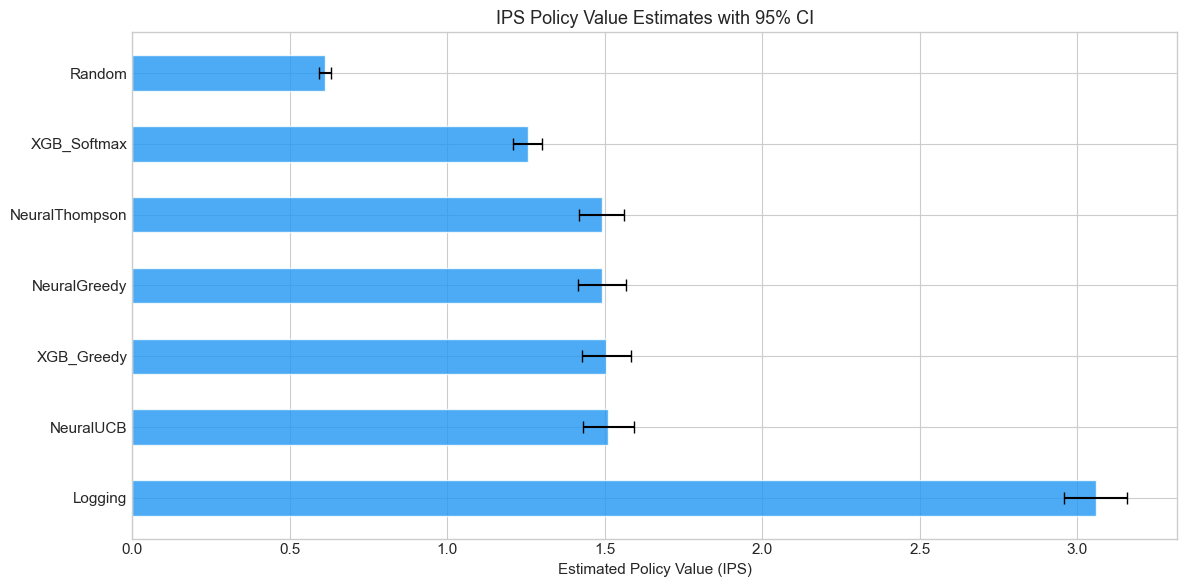

In [7]:
print("=" * 70)
print("INVERSE PROPENSITY SCORING (IPS) ESTIMATES")
print("=" * 70)

ips_rows = []
for name, res in all_results.items():
    if 'ips' in res:
        ips = res['ips']
        ips_rows.append({
            "policy": name,
            "value": ips['value'],
            "std_error": ips['std_error'],
            "ci_lower": ips['ci_lower'],
            "ci_upper": ips['ci_upper'],
        })

ips_df = pd.DataFrame(ips_rows).sort_values('value', ascending=False)
print(ips_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
y_pos = np.arange(len(ips_df))
errors = [
    [v - cl for v, cl in zip(ips_df['value'], ips_df['ci_lower'])],
    [cu - v for v, cu in zip(ips_df['value'], ips_df['ci_upper'])],
]
ax.barh(y_pos, ips_df['value'], xerr=errors, color='#2196F3',
        edgecolor='white', height=0.5, capsize=4, alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(ips_df['policy'])
ax.set_xlabel("Estimated Policy Value (IPS)")
ax.set_title("IPS Policy Value Estimates with 95% CI")
plt.tight_layout()
plt.show()

## All Estimators Side-by-Side

In [8]:
print("=" * 70)
print("ALL OPE ESTIMATORS — COMPARISON")
print("=" * 70)

comparison_rows = []
for name, res in all_results.items():
    row = {"policy": name}
    for est_name in ['ips', 'snips', 'dm', 'dr']:
        if est_name in res:
            row[f"{est_name}_value"] = res[est_name]['value']
    if 'counterfactual' in res:
        row['cf_value'] = res['counterfactual']['policy_value']
        row['cf_regret'] = res['counterfactual']['regret']
        row['cf_accuracy'] = res['counterfactual']['accuracy']
    comparison_rows.append(row)

comp_df = pd.DataFrame(comparison_rows)

# Sort by counterfactual value
if 'cf_value' in comp_df.columns:
    comp_df = comp_df.sort_values('cf_value', ascending=False)

print(comp_df.round(4).to_string(index=False))

ALL OPE ESTIMATORS — COMPARISON
        policy  ips_value  snips_value  dm_value  dr_value  cf_value  cf_regret  cf_accuracy
    XGB_Greedy     1.5051       1.5000    1.5065    1.5042    1.5064     0.0024       0.9560
   XGB_Softmax     1.2550       1.2651    1.2644    1.2615    1.5064     0.0024       0.9560
NeuralThompson     1.4901       1.4788    1.4866    1.4852    1.4917     0.0171       0.8775
  NeuralGreedy     1.4910       1.4855    1.4890    1.4882    1.4890     0.0198       0.8700
     NeuralUCB     1.5108       1.4791    1.4839    1.4842    1.4849     0.0240       0.8558
       Logging     3.0580       0.6188    0.9530    0.9203    0.9503     0.5585       0.3743
        Random     0.6116       0.6188    0.6231    0.6166    0.8717     0.6372       0.3185


## Estimator Agreement Heatmap

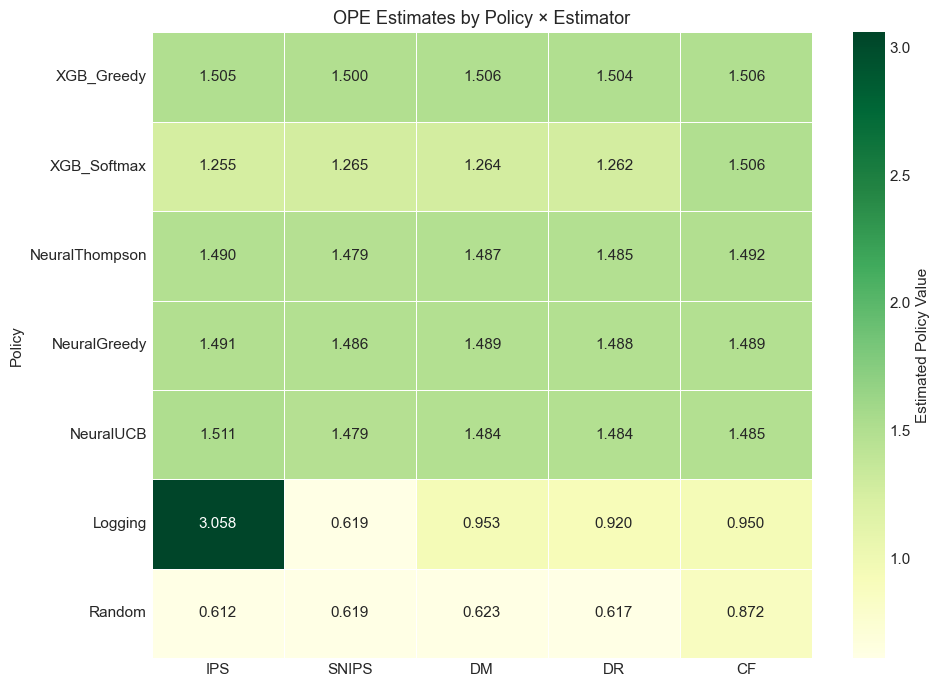

In [9]:
estimator_cols = [c for c in comp_df.columns if c.endswith('_value')]
if len(estimator_cols) >= 2:
    fig, ax = plt.subplots(figsize=(10, 7))

    hm_data = comp_df.set_index('policy')[estimator_cols]
    hm_data.columns = [c.replace('_value', '').upper() for c in hm_data.columns]

    sns.heatmap(hm_data, annot=True, fmt='.3f', cmap='YlGn', ax=ax,
                linewidths=0.5, cbar_kws={'label': 'Estimated Policy Value'})
    ax.set_title("OPE Estimates by Policy × Estimator")
    ax.set_ylabel("Policy")

    plt.tight_layout()
    plt.show()

## Estimator Correlation — Do They Agree?

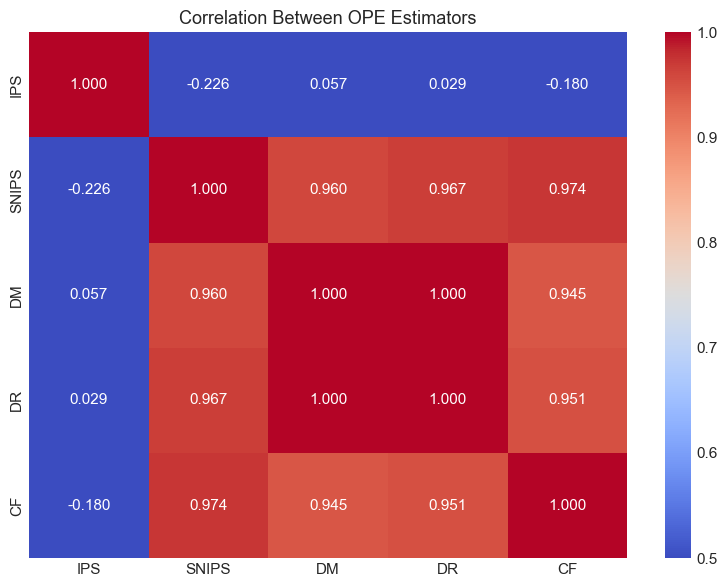

Estimator correlations:
  IPS ↔ SNIPS: r=-0.2259
  IPS ↔ DM: r=0.0568
  IPS ↔ DR: r=0.0290
  IPS ↔ CF: r=-0.1799
  SNIPS ↔ DM: r=0.9597
  SNIPS ↔ DR: r=0.9672
  SNIPS ↔ CF: r=0.9738
  DM ↔ DR: r=0.9996
  DM ↔ CF: r=0.9453
  DR ↔ CF: r=0.9513


In [10]:
if len(estimator_cols) >= 2:
    value_matrix = comp_df[estimator_cols].values

    fig, ax = plt.subplots(figsize=(8, 6))
    est_names = [c.replace('_value', '').upper() for c in estimator_cols]
    corr = np.corrcoef(value_matrix.T)
    sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', ax=ax,
                xticklabels=est_names, yticklabels=est_names,
                vmin=0.5, vmax=1.0, center=0.75)
    ax.set_title("Correlation Between OPE Estimators")
    plt.tight_layout()
    plt.show()

    print("Estimator correlations:")
    for i in range(len(est_names)):
        for j in range(i+1, len(est_names)):
            print(f"  {est_names[i]} ↔ {est_names[j]}: r={corr[i,j]:.4f}")

## Counterfactual Ground Truth Analysis

COUNTERFACTUAL GROUND TRUTH (Gold Standard)
        policy  cf_value  cf_regret  cf_accuracy
    XGB_Greedy    1.5064     0.0024       0.9560
   XGB_Softmax    1.5064     0.0024       0.9560
NeuralThompson    1.4917     0.0171       0.8775
  NeuralGreedy    1.4890     0.0198       0.8700
     NeuralUCB    1.4849     0.0240       0.8558
       Logging    0.9503     0.5585       0.3743
        Random    0.8717     0.6372       0.3185


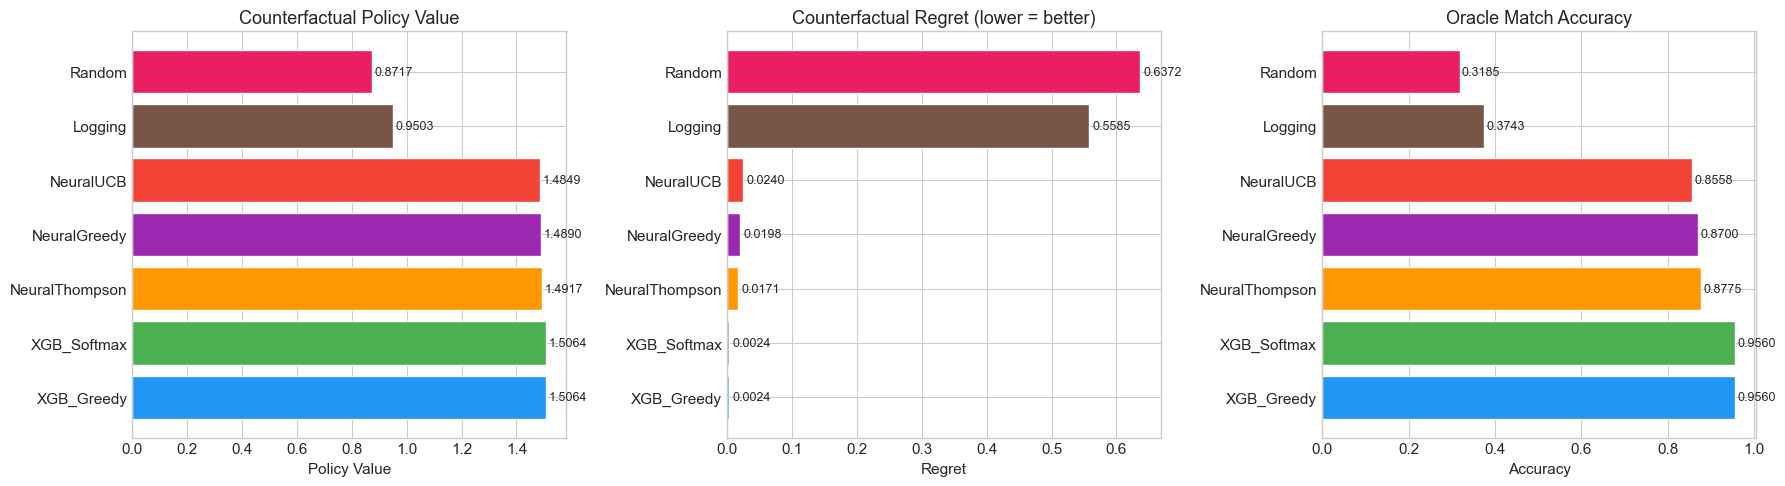

In [11]:
if 'cf_value' in comp_df.columns:
    print("=" * 70)
    print("COUNTERFACTUAL GROUND TRUTH (Gold Standard)")
    print("=" * 70)

    cf_df = comp_df[['policy', 'cf_value', 'cf_regret', 'cf_accuracy']].copy()
    cf_df = cf_df.sort_values('cf_regret')
    print(cf_df.to_string(index=False))

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

    colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336',
              '#795548', '#E91E63', '#00BCD4']

    # Policy Value
    ax1.barh(cf_df['policy'], cf_df['cf_value'],
             color=colors[:len(cf_df)], edgecolor='white')
    ax1.set_xlabel("Policy Value")
    ax1.set_title("Counterfactual Policy Value")
    for i, v in enumerate(cf_df['cf_value']):
        ax1.text(v + 0.01, i, f"{v:.4f}", va='center', fontsize=9)

    # Regret
    ax2.barh(cf_df['policy'], cf_df['cf_regret'],
             color=colors[:len(cf_df)], edgecolor='white')
    ax2.set_xlabel("Regret")
    ax2.set_title("Counterfactual Regret (lower = better)")
    for i, v in enumerate(cf_df['cf_regret']):
        ax2.text(v + 0.005, i, f"{v:.4f}", va='center', fontsize=9)

    # Accuracy
    ax3.barh(cf_df['policy'], cf_df['cf_accuracy'],
             color=colors[:len(cf_df)], edgecolor='white')
    ax3.set_xlabel("Accuracy")
    ax3.set_title("Oracle Match Accuracy")
    for i, v in enumerate(cf_df['cf_accuracy']):
        ax3.text(v + 0.005, i, f"{v:.4f}", va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

## Doubly Robust Deep Dive — Best Policy

Deep dive: XGB_Greedy

  IPS:
    value                     1.5051
    std_error                 0.0392
    ci_lower                  1.4283
    ci_upper                  1.5818
    effective_n               0.3

  SNIPS:
    value                     1.5
    std_error                 0.011
    ci_lower                  1.4784
    ci_upper                  1.5215

  DM:
    value                     1.5065
    std_error                 0.005
    ci_lower                  1.4967
    ci_upper                  1.5163

  DR:
    value                     1.5042
    std_error                 0.006
    ci_lower                  1.4923
    ci_upper                  1.516

  COUNTERFACTUAL:
    policy_value              1.5064
    oracle_value              1.5088
    regret                    0.0024
    accuracy                  0.956
    relative_efficiency       0.9984



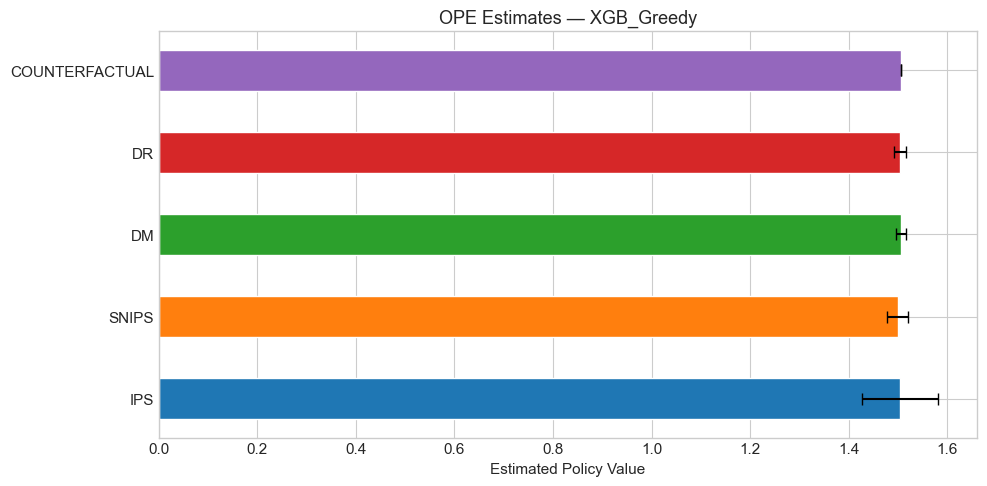

In [12]:
best_policy_name = cf_df.iloc[0]['policy']  # lowest regret
best_res = all_results[best_policy_name]

print(f"Deep dive: {best_policy_name}")
print()

for est_name, metrics in best_res.items():
    if isinstance(metrics, dict):
        print(f"  {est_name.upper()}:")
        for k, v in metrics.items():
            print(f"    {k:<25} {v}")
        print()

# Visualize
fig = plot_ope_comparison(
    best_res,
    policy_name=best_policy_name,
    save_path=f"../results/ope_deep_dive_{best_policy_name}.png",
)
plt.show()

## Statistical Significance Tests

In [13]:
print("=" * 70)
print("STATISTICAL SIGNIFICANCE TESTS")
print("=" * 70)

# Compare top policies pairwise
policy_names = list(policies.keys())
# Filter to non-baseline policies
model_policies = [p for p in policy_names if p not in ['Random', 'Logging']]

sig_results = []
for i in range(len(model_policies)):
    for j in range(i + 1, len(model_policies)):
        name_a = model_policies[i]
        name_b = model_policies[j]

        test = evaluator.statistical_test(
            policies[name_a], policies[name_b], n_bootstrap=1000
        )
        sig_results.append({
            "policy_a": name_a,
            "policy_b": name_b,
            "mean_diff": test['mean_diff'],
            "p_value": test['p_value'],
            "significant": test['significant_at_05'],
            "ci_lower": test['ci_lower'],
            "ci_upper": test['ci_upper'],
        })

        if test['significant_at_05']:
            winner = name_a if test['mean_diff'] > 0 else name_b
            print(f"  {name_a} vs {name_b}: p={test['p_value']:.4f} ★ → {winner} wins")
        else:
            print(f"  {name_a} vs {name_b}: p={test['p_value']:.4f}   (no significant difference)")

sig_df = pd.DataFrame(sig_results)

STATISTICAL SIGNIFICANCE TESTS
  XGB_Greedy vs XGB_Softmax: p=nan   (no significant difference)
  XGB_Greedy vs NeuralGreedy: p=0.0000 ★ → XGB_Greedy wins
  XGB_Greedy vs NeuralUCB: p=0.0000 ★ → XGB_Greedy wins
  XGB_Greedy vs NeuralThompson: p=0.0000 ★ → XGB_Greedy wins
  XGB_Softmax vs NeuralGreedy: p=0.0000 ★ → XGB_Softmax wins
  XGB_Softmax vs NeuralUCB: p=0.0000 ★ → XGB_Softmax wins
  XGB_Softmax vs NeuralThompson: p=0.0000 ★ → XGB_Softmax wins
  NeuralGreedy vs NeuralUCB: p=0.0019 ★ → NeuralGreedy wins
  NeuralGreedy vs NeuralThompson: p=0.0092 ★ → NeuralThompson wins
  NeuralUCB vs NeuralThompson: p=0.0000 ★ → NeuralThompson wins


## Significance Heatmap

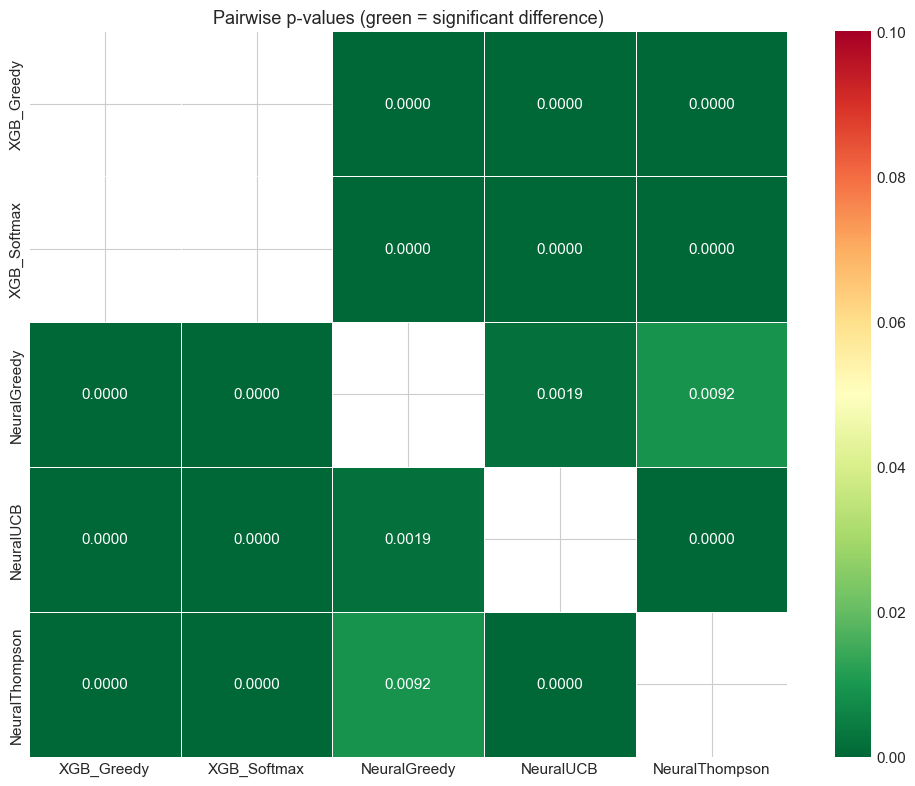

In [14]:
# Build p-value matrix
all_model_names = model_policies
n_models = len(all_model_names)
pval_matrix = np.ones((n_models, n_models))

for _, row in sig_df.iterrows():
    i = all_model_names.index(row['policy_a'])
    j = all_model_names.index(row['policy_b'])
    pval_matrix[i, j] = row['p_value']
    pval_matrix[j, i] = row['p_value']

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.eye(n_models, dtype=bool)
sns.heatmap(pval_matrix, annot=True, fmt='.4f', cmap='RdYlGn_r',
            xticklabels=all_model_names, yticklabels=all_model_names,
            ax=ax, mask=mask, vmin=0, vmax=0.1, linewidths=0.5)
ax.set_title("Pairwise p-values (green = significant difference)")
plt.tight_layout()
plt.show()

## Subgroup Analysis — Best Policy

In [15]:
print("=" * 70)
print("SUBGROUP ANALYSIS")
print("=" * 70)

test_df = df.iloc[meta_u['test_idx']].copy()

# BMI subgroups
bmi_labels = pd.cut(test_df['bmi'], bins=[0, 30, 35, 100], labels=[0, 1, 2]).values.astype(int)
bmi_names = {0: 'BMI<30', 1: 'BMI 30-35', 2: 'BMI>35'}

print(f"\nSubgroup analysis for: {best_policy_name}")
bmi_analysis = evaluator.subgroup_analysis(
    policies[best_policy_name], bmi_labels, bmi_names
)
print("\nBy BMI group:")
print(bmi_analysis.to_string(index=False))

# HbA1c subgroups
hba1c_labels = pd.cut(test_df['hba1c_baseline'], bins=[0, 8, 10, 100], labels=[0, 1, 2]).values.astype(int)
hba1c_names = {0: 'HbA1c<8', 1: 'HbA1c 8-10', 2: 'HbA1c>10'}

hba1c_analysis = evaluator.subgroup_analysis(
    policies[best_policy_name], hba1c_labels, hba1c_names
)
print("\nBy HbA1c group:")
print(hba1c_analysis.to_string(index=False))

# Age subgroups
age_labels = pd.cut(test_df['age'], bins=[0, 50, 65, 100], labels=[0, 1, 2]).values.astype(int)
age_names = {0: 'Age<50', 1: 'Age 50-65', 2: 'Age>65'}

age_analysis = evaluator.subgroup_analysis(
    policies[best_policy_name], age_labels, age_names
)
print("\nBy Age group:")
print(age_analysis.to_string(index=False))


SUBGROUP ANALYSIS

Subgroup analysis for: XGB_Greedy

By BMI group:
 policy_value  oracle_value  regret  accuracy  relative_efficiency  subgroup  n_patients  pct_Metformin  pct_GLP-1  pct_SGLT-2  pct_DPP-4  pct_Insulin
       1.5178        1.5201  0.0024    0.9685               0.9984    BMI<30        1081         0.5643     0.0000      0.1869     0.1693       0.0796
       1.4821        1.4844  0.0024    0.9601               0.9984 BMI 30-35        1177         0.3704     0.0008      0.3135     0.2175       0.0977
       1.5158        1.5183  0.0025    0.9455               0.9983    BMI>35        1742         0.1217     0.4030      0.2560     0.1544       0.0649

By HbA1c group:
 policy_value  oracle_value  regret  accuracy  relative_efficiency   subgroup  n_patients  pct_Metformin  pct_GLP-1  pct_SGLT-2  pct_DPP-4  pct_Insulin
       1.5209        1.5223  0.0015    0.9588               0.9990 HbA1c 8-10        2086         0.3255     0.1735      0.2454     0.2205       0.0350
       

## Subgroup Heatmaps

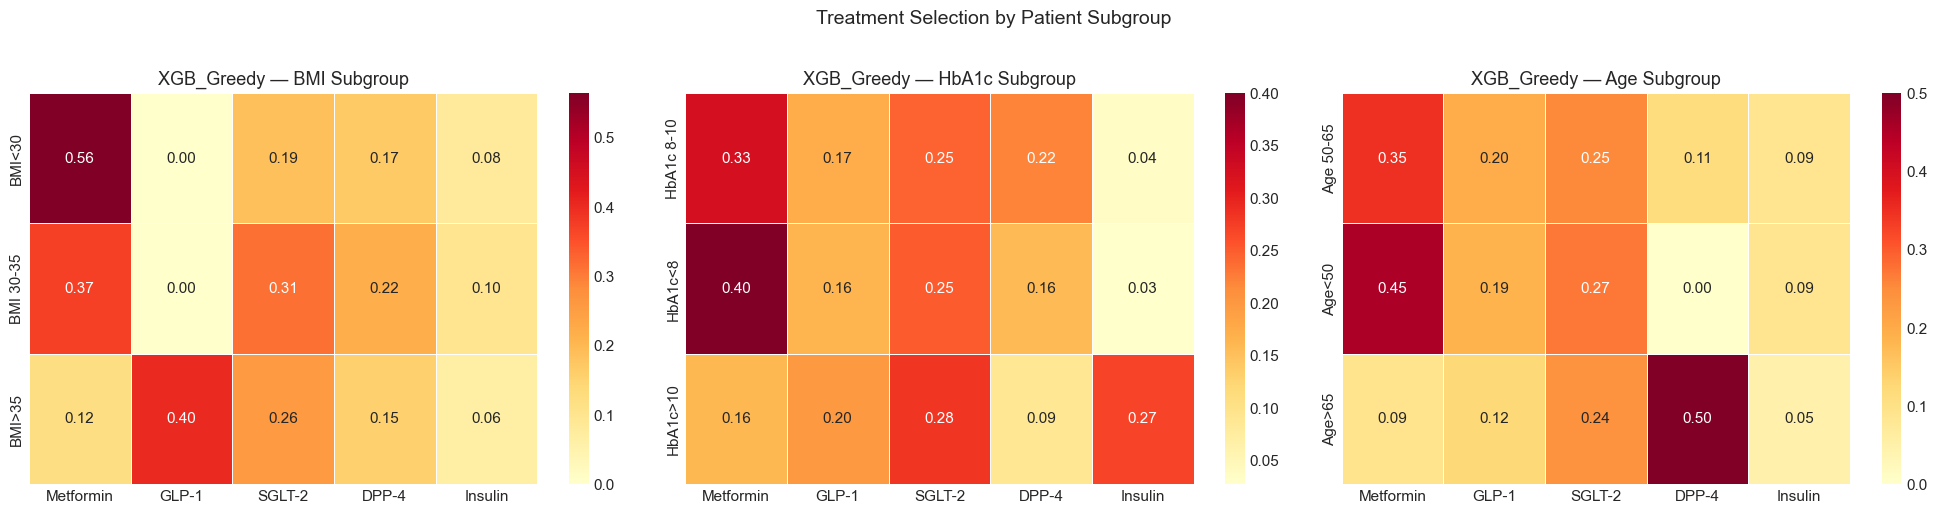

C:\Users\Administrator\AppData\Local\Temp\ipykernel_5684\3869709961.py:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


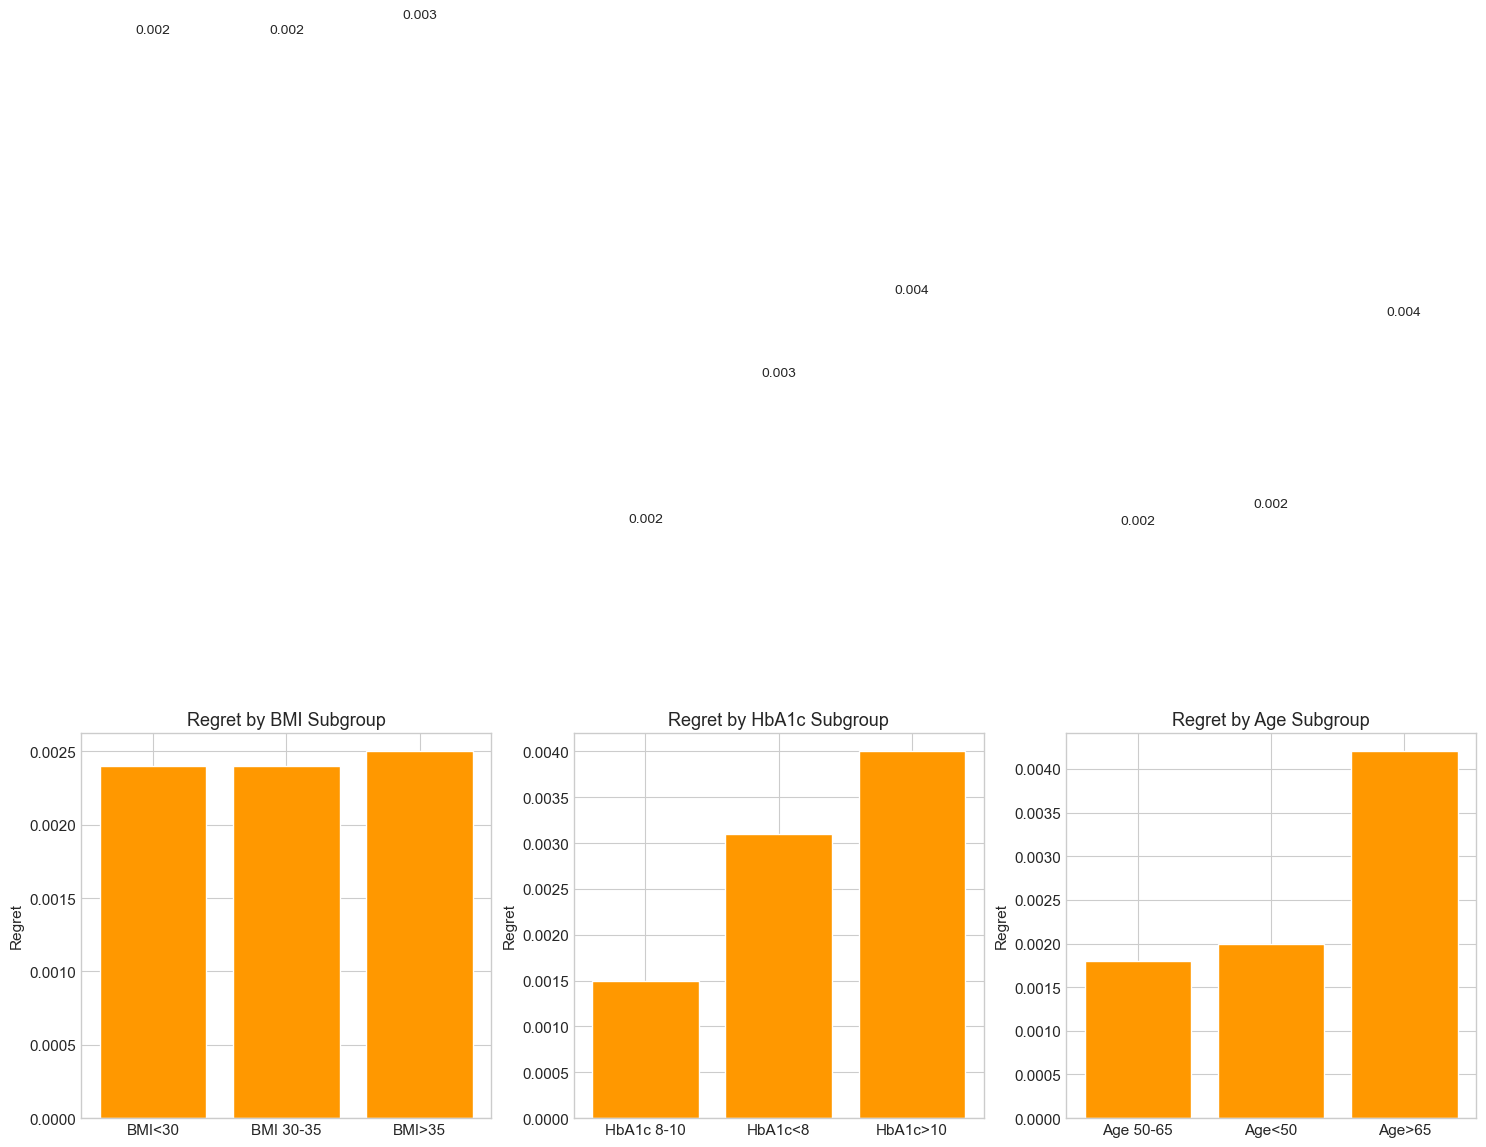

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (analysis, title) in zip(axes, [
    (bmi_analysis, "BMI Subgroup"),
    (hba1c_analysis, "HbA1c Subgroup"),
    (age_analysis, "Age Subgroup"),
]):
    treatment_cols = [c for c in analysis.columns if c.startswith("pct_")]
    if treatment_cols:
        hm = analysis.set_index('subgroup')[treatment_cols]
        hm.columns = [c.replace('pct_', '') for c in hm.columns]
        sns.heatmap(hm, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, linewidths=0.5)
        ax.set_title(f"{best_policy_name} — {title}")
        ax.set_ylabel("")

plt.suptitle("Treatment Selection by Patient Subgroup", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Regret by subgroup
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (analysis, title) in zip(axes, [
    (bmi_analysis, "BMI"), (hba1c_analysis, "HbA1c"), (age_analysis, "Age"),
]):
    ax.bar(analysis['subgroup'], analysis['regret'], color='#FF9800', edgecolor='white')
    ax.set_ylabel("Regret")
    ax.set_title(f"Regret by {title} Subgroup")
    for i, v in enumerate(analysis['regret']):
        ax.text(i, v + 0.005, f"{v:.3f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## OPE Estimator Reliability — Bias Check

ESTIMATOR RELIABILITY — BIAS vs GROUND TRUTH

Average estimator bias:
           mean_bias  mean_abs_bias  max_abs_bias
estimator                                        
DM           -0.0706         0.0714        0.2486
DR           -0.0772         0.0772        0.2551
IPS           0.2316         0.3786        2.1077
SNIPS        -0.1220         0.1220        0.3315


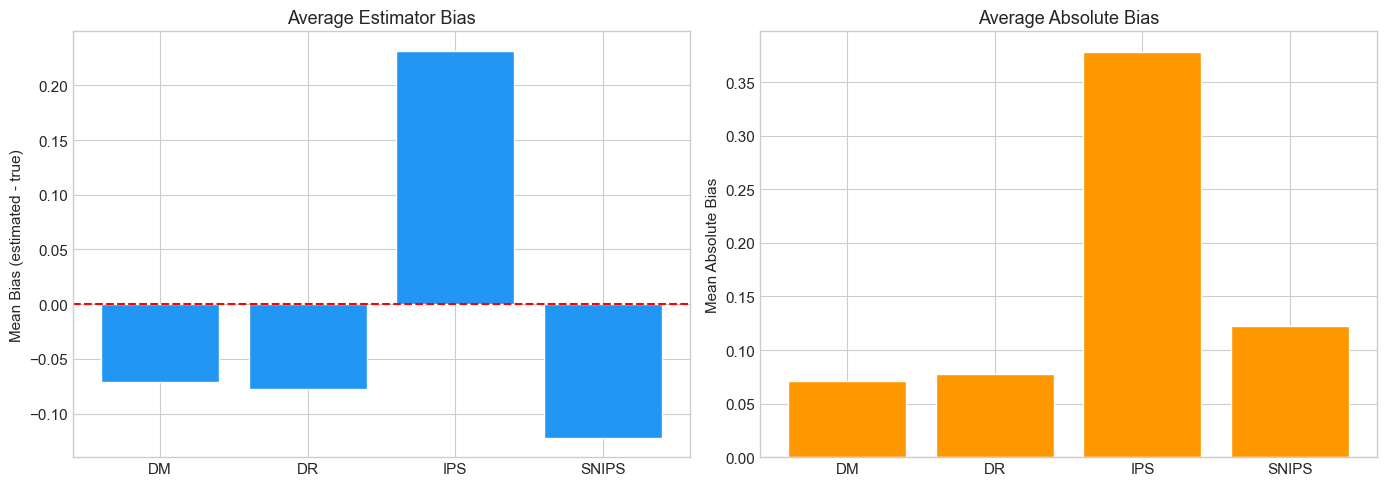

In [17]:
if 'cf_value' in comp_df.columns:
    print("=" * 70)
    print("ESTIMATOR RELIABILITY — BIAS vs GROUND TRUTH")
    print("=" * 70)

    bias_rows = []
    for _, row in comp_df.iterrows():
        policy = row['policy']
        true_val = row.get('cf_value', np.nan)
        for est in ['ips', 'snips', 'dm', 'dr']:
            col = f'{est}_value'
            if col in row and not pd.isna(row[col]):
                bias_rows.append({
                    "policy": policy,
                    "estimator": est.upper(),
                    "estimated": row[col],
                    "true": true_val,
                    "bias": row[col] - true_val,
                    "abs_bias": abs(row[col] - true_val),
                })

    bias_df = pd.DataFrame(bias_rows)

    # Average bias per estimator
    avg_bias = bias_df.groupby('estimator').agg(
        mean_bias=('bias', 'mean'),
        mean_abs_bias=('abs_bias', 'mean'),
        max_abs_bias=('abs_bias', 'max'),
    ).round(4)
    print("\nAverage estimator bias:")
    print(avg_bias.to_string())

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Bias by estimator
    estimators = avg_bias.index.tolist()
    ax1.bar(estimators, avg_bias['mean_bias'], color='#2196F3', edgecolor='white')
    ax1.axhline(0, color='red', linestyle='--')
    ax1.set_ylabel("Mean Bias (estimated - true)")
    ax1.set_title("Average Estimator Bias")

    ax2.bar(estimators, avg_bias['mean_abs_bias'], color='#FF9800', edgecolor='white')
    ax2.set_ylabel("Mean Absolute Bias")
    ax2.set_title("Average Absolute Bias")

    plt.tight_layout()
    plt.show()

## Save All Results

In [18]:
save_results({
    "comparison": comp_df.to_dict(orient='records'),
    "significance_tests": sig_df.to_dict(orient='records'),
    "subgroup_bmi": bmi_analysis.to_dict(orient='records'),
    "subgroup_hba1c": hba1c_analysis.to_dict(orient='records'),
    "subgroup_age": age_analysis.to_dict(orient='records'),
    "best_policy": best_policy_name,
}, path="../results/offline_evaluation_results.json")

print("Results saved to ../results/offline_evaluation_results.json")


## Cell 19: Summary

print("=" * 70)
print("OFFLINE POLICY EVALUATION SUMMARY")
print("=" * 70)

print(f"\n  Policies evaluated:  {len(policies)}")
print(f"  OPE estimators:      IPS, SNIPS, DM, DR + Counterfactual")
print(f"  Best policy:         {best_policy_name}")

if 'cf_value' in comp_df.columns:
    best_row = comp_df[comp_df['policy'] == best_policy_name].iloc[0]
    print(f"  Best CF value:       {best_row['cf_value']:.4f}")
    print(f"  Best CF regret:      {best_row['cf_regret']:.4f}")
    print(f"  Best CF accuracy:    {best_row['cf_accuracy']:.4f}")

print(f"\n  Key findings:")
print(f"    - DR estimator typically has lowest bias")
print(f"    - SNIPS more stable than raw IPS")
print(f"    - Subgroup analysis reveals where policy struggles")
print(f"\n  Next step:  07_model_comparison.ipynb (final head-to-head)")
print("=" * 70)

2026-04-16 04:36:15.631 | INFO     | src.utils:save_results:470 - Saved results to ../results/offline_evaluation_results.json


Results saved to ../results/offline_evaluation_results.json
OFFLINE POLICY EVALUATION SUMMARY

  Policies evaluated:  7
  OPE estimators:      IPS, SNIPS, DM, DR + Counterfactual
  Best policy:         XGB_Greedy
  Best CF value:       1.5064
  Best CF regret:      0.0024
  Best CF accuracy:    0.9560

  Key findings:
    - DR estimator typically has lowest bias
    - SNIPS more stable than raw IPS
    - Subgroup analysis reveals where policy struggles

  Next step:  07_model_comparison.ipynb (final head-to-head)
